## K2000 run for vanilla FEM : 
Naive run and improved hyperparams run (more replicas/ n_steps/ explicit gradient)

In [1]:
from pathlib import Path
import time
import torch
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print("Using device:", device)

Using device: mps


In [3]:
K2000_PATH = Path("WK2000_1.rud")
K2000_INSTANCE = "K2000"
K2000_N_EXPECTED = 2000
K2000_M_EXPECTED = 1_999_000
K2000_BEST_KNOWN = 33337
K2000_PATH

PosixPath('WK2000_1.rud')

In [4]:
K2000_TMAX = 1.16
K2000_TMIN = 6e-05

K2000_BETA_MIN = 1.0 / K2000_TMAX
K2000_BETA_MAX = 1.0 / K2000_TMIN

print("beta_min =", K2000_BETA_MIN)
print("beta_max =", K2000_BETA_MAX)

beta_min = 0.8620689655172414
beta_max = 16666.666666666668


### Data inspection

In [5]:
with K2000_PATH.open("r") as f:
    header = f.readline().strip()
    preview_edges = [f.readline().strip() for _ in range(5)]
print("Header line:")
print(header)

print(f"\nFirst {5} edge lines:")
for line in preview_edges:
    print(line)

header_parts = header.split()

if len(header_parts) != 2:
    raise ValueError(
        f"Bad header format: {header!r}. "
        "Expected exactly two integers: N M"
    )

N_header = int(header_parts[0])
M_header = int(header_parts[1])

print("\nParsed header:")
print("N_header =", N_header)
print("M_header =", M_header)

Header line:
2000 1999000

First 5 edge lines:
1 2000 -1
1 1999 -1
1 1998 -1
1 1997 -1
1 1996 1

Parsed header:
N_header = 2000
M_header = 1999000


In [6]:
# ----------------------------
# Inspect preview edge format
# ----------------------------

print("\nPreview edge parsing:")

for idx, line in enumerate(preview_edges, start=1):
    parts = line.split()

    if len(parts) != 3:
        raise ValueError(
            f"Bad edge line in preview at preview line {idx}: {line!r}. "
            "Expected format: i j w"
        )

    i, j, w = map(int, parts)

    print(f"edge {idx}: i={i}, j={j}, w={w}")

    if not (1 <= i <= N_header):
        raise ValueError(f"Node i out of range in preview: i={i}")

    if not (1 <= j <= N_header):
        raise ValueError(f"Node j out of range in preview: j={j}")

    if w not in (-1, 1):
        raise ValueError(f"Unexpected weight in preview: w={w}")


Preview edge parsing:
edge 1: i=1, j=2000, w=-1
edge 2: i=1, j=1999, w=-1
edge 3: i=1, j=1998, w=-1
edge 4: i=1, j=1997, w=-1
edge 5: i=1, j=1996, w=1


#### Load adjacency matrix

In [7]:
def load_k2000_dense(path, device="cpu", dtype=torch.float32):

    path = Path(path)

    if not path.exists():
        raise FileNotFoundError(f"Could not find K2000 file: {path.resolve()}")

    with path.open("r") as f:
        # ----------------------------
        # Header: N M
        # ----------------------------
        header = f.readline().strip().split()

        if len(header) != 2:
            raise ValueError(
                f"Bad header in {path}: {header}. "
                "Expected exactly: N M"
            )

        n = int(header[0])
        m_header = int(header[1])

        # Dense adjacency matrix
        W = torch.zeros((n, n), dtype=dtype, device=device)

        # Counters
        m_loaded = 0
        positive_edges = 0
        negative_edges = 0
        self_edges = 0

        # ----------------------------
        # Edge lines: i j w
        # ----------------------------
        for line_no, line in enumerate(f, start=2):
            line = line.strip()

            if not line:
                continue

            parts = line.split()

            if len(parts) != 3:
                raise ValueError(
                    f"Bad edge line {line_no}: {line!r}. "
                    "Expected exactly: i j w"
                )

            i, j, w = map(int, parts)

            # Convert 1-indexed file labels to 0-indexed tensor indices
            i -= 1
            j -= 1

            if not (0 <= i < n):
                raise IndexError(f"Line {line_no}: i index out of range: {i}")

            if not (0 <= j < n):
                raise IndexError(f"Line {line_no}: j index out of range: {j}")

            if w not in (-1, 1):
                raise ValueError(
                    f"Line {line_no}: unexpected K2000 weight {w}. "
                    "Expected -1 or +1."
                )

            if i == j:
                self_edges += 1

            # Symmetric undirected graph
            W[i, j] = float(w)
            W[j, i] = float(w)

            m_loaded += 1

            if w == 1:
                positive_edges += 1
            else:
                negative_edges += 1

    # ----------------------------
    # Metadata / sanity information
    # ----------------------------
    diag_zero = bool(torch.allclose(
        torch.diag(W),
        torch.zeros(n, dtype=dtype, device=device)
    ))

    symmetric = bool(torch.allclose(W, W.T))

    nonzero_directed = int((W != 0).sum().detach().cpu().item())

    info = {
        "path": str(path),
        "n": n,
        "m_header": m_header,
        "m_loaded": m_loaded,
        "positive_edges": positive_edges,
        "negative_edges": negative_edges,
        "self_edges": self_edges,
        "nonzero_directed_entries": nonzero_directed,
        "expected_directed_entries": n * (n - 1),
        "symmetric": symmetric,
        "diag_zero": diag_zero,
        "W_sum": float(W.sum().detach().cpu().item()),
        "W_min": float(W.min().detach().cpu().item()),
        "W_max": float(W.max().detach().cpu().item()),
    }

    return W, info

In [8]:
W, k2000_info = load_k2000_dense(
    K2000_PATH,
    device="cpu",
    dtype=torch.float32,
)

# ----------------------------
# Print metadata
# ----------------------------

print("Loaded K2000.")
print("-" * 80)

for key, value in k2000_info.items():
    print(f"{key}: {value}")

print("-" * 80)

Loaded K2000.
--------------------------------------------------------------------------------
path: WK2000_1.rud
n: 2000
m_header: 1999000
m_loaded: 1999000
positive_edges: 998980
negative_edges: 1000020
self_edges: 0
nonzero_directed_entries: 3998000
expected_directed_entries: 3998000
symmetric: True
diag_zero: True
W_sum: -2080.0
W_min: -1.0
W_max: 1.0
--------------------------------------------------------------------------------


In [9]:
W = W.to(device)
print(W.device)

mps:0


In [10]:
assert k2000_info["n"] == K2000_N_EXPECTED, (
    f"Expected {K2000_N_EXPECTED} nodes, got {k2000_info['n']}"
)
assert k2000_info["m_header"] == K2000_M_EXPECTED, (
    f"Expected header edge count {K2000_M_EXPECTED}, "
    f"got {k2000_info['m_header']}"
)
assert k2000_info["m_loaded"] == K2000_M_EXPECTED, (
    f"Expected loaded edge count {K2000_M_EXPECTED}, "
    f"got {k2000_info['m_loaded']}"
)
assert k2000_info["self_edges"] == 0, (
    f"Expected no self edges, got {k2000_info['self_edges']}"
)
assert k2000_info["symmetric"] is True, "W is not symmetric."
assert k2000_info["diag_zero"] is True, "Diagonal of W is not zero."
assert k2000_info["nonzero_directed_entries"] == k2000_info["expected_directed_entries"], (
    f"Expected {k2000_info['expected_directed_entries']} directed nonzero entries, "
    f"got {k2000_info['nonzero_directed_entries']}"
)
assert k2000_info["W_min"] == -1.0, (
    f"Expected W_min = -1.0, got {k2000_info['W_min']}"
)
assert k2000_info["W_max"] == 1.0, (
    f"Expected W_max = 1.0, got {k2000_info['W_max']}"
)
assert (
    k2000_info["positive_edges"] + k2000_info["negative_edges"]
    == K2000_M_EXPECTED
), "Positive + negative edge count does not match expected edge count."

In [11]:
num_nodes = k2000_info["n"]
num_edges = k2000_info["m_loaded"]
positive_edges = k2000_info["positive_edges"]
negative_edges = k2000_info["negative_edges"]

positive_fraction = positive_edges / num_edges
negative_fraction = negative_edges / num_edges

print("Sanity checks passed.")
print("-" * 80)
print("W.shape:", tuple(W.shape))
print("W dtype:", W.dtype)
print("W device:", W.device)
print("Positive edges:", positive_edges, f"({100 * positive_fraction:.4f}%)")
print("Negative edges:", negative_edges, f"({100 * negative_fraction:.4f}%)")
print("Total undirected edges:", num_edges)
print("Total directed nonzero entries:", k2000_info["nonzero_directed_entries"])
print("Best-known K2000 cut:", K2000_BEST_KNOWN)

Sanity checks passed.
--------------------------------------------------------------------------------
W.shape: (2000, 2000)
W dtype: torch.float32
W device: mps:0
Positive edges: 998980 (49.9740%)
Negative edges: 1000020 (50.0260%)
Total undirected edges: 1999000
Total directed nonzero entries: 3998000
Best-known K2000 cut: 33337


## Data is loaded, adjacency matrix is set. Moving on to FEM workflow

In [12]:
def expected_cut(W, p):
    squeeze_output = False
    if p.dim() == 1:
        p = p.unsqueeze(0)
        squeeze_output = True
    p = p.to(W.device, dtype=W.dtype)
    cut_exp = torch.einsum("ri,ij,rj->r", p, W, 1.0 - p)
    if squeeze_output:
        return cut_exp.squeeze(0)
    return cut_exp

In [13]:
def discrete_cut(W, spins):
    squeeze_output = False

    if spins.dim() == 1:
        spins = spins.unsqueeze(0)
        squeeze_output = True

    spins = spins.to(W.device, dtype=W.dtype)
    quad = torch.einsum("ri,ij,rj->r", spins, W, spins)
    cut = 0.25 * (W.sum() - quad)
    if squeeze_output:
        return cut.squeeze(0)

    return cut

In [14]:
def binary_entropy(p, eps=1e-12):
    squeeze_output = False

    if p.dim() == 1:
        p = p.unsqueeze(0)
        squeeze_output = True

    p = p.clamp(eps, 1.0 - eps)

    S = -(
        p * torch.log(p)
        + (1.0 - p) * torch.log(1.0 - p)
    ).sum(dim=1)

    if squeeze_output:
        return S.squeeze(0)

    return S

## Define Free energy

In [15]:
def fem_free_energy_maxcut(W, h, beta):
    p = torch.sigmoid(h)
    E_cut = expected_cut(W, p)
    S = binary_entropy(p)
    beta = torch.as_tensor(beta, dtype=W.dtype, device=W.device)

    F = -E_cut - S / beta
    return F

#### Beta schedule

In [16]:
def make_beta_schedule(
    n_steps,
    Tmax=K2000_TMAX,
    Tmin=K2000_TMIN,
    device=device,
    dtype=torch.float32,
):
    if n_steps <= 0:
        raise ValueError("n_steps must be positive.")

    if Tmax <= 0 or Tmin <= 0:
        raise ValueError("Tmax and Tmin must both be positive.")

    if Tmax <= Tmin:
        raise ValueError(
            f"Expected Tmax > Tmin for cooling, got Tmax={Tmax}, Tmin={Tmin}"
        )

    T_schedule = torch.linspace(
        Tmax,
        Tmin,
        n_steps,
        device=device,
        dtype=dtype,
    )

    beta_schedule = 1.0 / T_schedule
    return beta_schedule

In [17]:
beta_preview = make_beta_schedule(n_steps=1000)

print("beta shape:", beta_preview.shape)
print("beta first:", beta_preview[0].detach().cpu().item())
print("beta middle:", beta_preview[len(beta_preview)//2].detach().cpu().item())
print("beta last:", beta_preview[-1].detach().cpu().item())

beta shape: torch.Size([1000])
beta first: 0.8620690107345581
beta middle: 1.725776195526123
beta last: 16666.66796875


## First RUN

In [18]:
# ----------------------------
# Run hyperparameters
# ----------------------------

R = 128
n_steps = 1000

lr = 0.01
h_factor = 0.001
seed = 4

log_every = 50

best_known = K2000_BEST_KNOWN

# ----------------------------
# Basic graph dimensions
# ----------------------------

N = W.shape[0]

print("K2000 vanilla FEM Adam setup")
print("-" * 80)
print("N:", N)
print("R:", R)
print("n_steps:", n_steps)
print("lr:", lr)
print("h_factor:", h_factor)
print("seed:", seed)
print("log_every:", log_every)
print("best_known:", best_known)
print("device:", W.device)
print("dtype:", W.dtype)
print("-" * 80)

K2000 vanilla FEM Adam setup
--------------------------------------------------------------------------------
N: 2000
R: 128
n_steps: 1000
lr: 0.01
h_factor: 0.001
seed: 4
log_every: 50
best_known: 33337
device: mps:0
dtype: torch.float32
--------------------------------------------------------------------------------


In [19]:
# ----------------------------
# Beta schedule
# ----------------------------

beta_schedule = make_beta_schedule(
    n_steps=n_steps,
    Tmax=K2000_TMAX,
    Tmin=K2000_TMIN,
    device=W.device,
    dtype=W.dtype,
)

print("beta first:", beta_schedule[0].detach().cpu().item())
print("beta last :", beta_schedule[-1].detach().cpu().item())

beta first: 0.8620690107345581
beta last : 16666.66796875


In [20]:
torch.manual_seed(seed)

h = h_factor * torch.randn(
    R,
    N,
    device=W.device,
    dtype=W.dtype,
)

h.requires_grad_(True)

with torch.no_grad():
    p_init = torch.sigmoid(h)

print("\nInitialization check:")
print("h mean:", h.mean().detach().cpu().item())
print("h std :", h.std().detach().cpu().item())
print("p mean:", p_init.mean().detach().cpu().item())
print("p std :", p_init.std().detach().cpu().item())


Initialization check:
h mean: -1.0695375749492086e-06
h std : 0.0010001646587625146
p mean: 0.4999997615814209
p std : 0.0002500432019587606


In [21]:
# ----------------------------
# Optimizer
# ----------------------------

optimizer = torch.optim.Adam(
    [h],
    lr=lr,
)

print("\nOptimizer:")
print(optimizer)


Optimizer:
Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.01
    maximize: False
    weight_decay: 0
)


# K2000 run

In [22]:
history = []

best_cut = None
best_step = None
best_replica = None
best_spins = None
best_p = None

start_time = None

In [23]:
start_time = time.time()

if W.device.type == "mps":
    torch.mps.synchronize()

for step in range(n_steps):
    beta_t = beta_schedule[step]

    # ----------------------------
    # FEM gradient step
    # ----------------------------

    optimizer.zero_grad()

    F = fem_free_energy_maxcut(W, h, beta_t)

    # Optimize the average free energy over replicas
    loss = F.mean()

    loss.backward()
    optimizer.step()

    # ----------------------------
    # Logging and hard readout
    # ----------------------------

    should_log = (
        step == 0
        or step == n_steps - 1
        or (step + 1) % log_every == 0
    )

    if should_log:
        if W.device.type == "mps":
            torch.mps.synchronize()

        elapsed = time.time() - start_time

        with torch.no_grad():
            p = torch.sigmoid(h)

            E_cut = expected_cut(W, p)
            S = binary_entropy(p)

            spins = torch.where(
                p >= 0.5,
                torch.ones_like(p),
                -torch.ones_like(p),
            )

            H_cut = discrete_cut(W, spins)

            current_best_cut, current_best_replica = torch.max(H_cut, dim=0)

            current_best_cut_value = float(current_best_cut.detach().cpu().item())
            current_best_replica_value = int(current_best_replica.detach().cpu().item())

            # Update global best over the full run
            if best_cut is None or current_best_cut_value > best_cut:
                best_cut = current_best_cut_value
                best_step = step + 1
                best_replica = current_best_replica_value
                best_spins = spins[current_best_replica_value].detach().clone()
                best_p = p[current_best_replica_value].detach().clone()

            history.append({
                "step": step + 1,
                "beta": float(beta_t.detach().cpu().item()),

                "loss_mean": float(loss.detach().cpu().item()),
                "F_mean": float(F.mean().detach().cpu().item()),
                "F_min": float(F.min().detach().cpu().item()),

                "Ecut_mean": float(E_cut.mean().detach().cpu().item()),
                "Ecut_max": float(E_cut.max().detach().cpu().item()),

                "entropy_mean": float(S.mean().detach().cpu().item()),

                "Hcut_mean": float(H_cut.mean().detach().cpu().item()),
                "Hcut_max": current_best_cut_value,

                "best_cut_so_far": best_cut,
                "gap_so_far": float(best_known - best_cut),
                "accuracy_so_far_percent": float(100.0 * best_cut / best_known),

                "best_replica_current": current_best_replica_value,
                "best_replica_so_far": best_replica,

                "elapsed_sec": elapsed,
            })

            print(
                f"step {step + 1:5d}/{n_steps} | "
                f"beta={float(beta_t.detach().cpu().item()):10.4f} | "
                f"loss={float(loss.detach().cpu().item()):12.4f} | "
                f"Ecut_max={float(E_cut.max().detach().cpu().item()):10.1f} | "
                f"Hcut_max={current_best_cut_value:10.1f} | "
                f"best={best_cut:10.1f} | "
                f"acc={100.0 * best_cut / best_known:8.4f}% | "
                f"time={elapsed:8.2f}s"
            )

if W.device.type == "mps":
    torch.mps.synchronize()

total_time_sec = time.time() - start_time

step     1/1000 | beta=    0.8621 | loss=  -1088.1013 | Ecut_max=    -519.9 | Hcut_max=     654.0 | best=     654.0 | acc=  1.9618% | time=    0.06s
step    50/1000 | beta=    0.9065 | loss=  -3031.9678 | Ecut_max=    1750.6 | Hcut_max=   28191.0 | best=   28191.0 | acc= 84.5637% | time=    0.21s
step   100/1000 | beta=    0.9569 | loss=  -9836.8203 | Ecut_max=    9108.8 | Hcut_max=   28810.0 | best=   28810.0 | acc= 86.4205% | time=    0.48s
step   150/1000 | beta=    1.0132 | loss= -16367.9473 | Ecut_max=   16096.2 | Hcut_max=   29222.0 | best=   29222.0 | acc= 87.6564% | time=    0.75s
step   200/1000 | beta=    1.0765 | loss= -20460.0684 | Ecut_max=   20487.5 | Hcut_max=   29293.0 | best=   29293.0 | acc= 87.8693% | time=    0.96s
step   250/1000 | beta=    1.1483 | loss= -22884.4551 | Ecut_max=   23112.4 | Hcut_max=   29421.0 | best=   29421.0 | acc= 88.2533% | time=    1.18s
step   300/1000 | beta=    1.2303 | loss= -24395.9219 | Ecut_max=   24762.3 | Hcut_max=   29523.0 | best= 

In [24]:
history_k2000_adam = pd.DataFrame(history)
with torch.no_grad():
    p_final = torch.sigmoid(h)

    spins_final = torch.where(
        p_final >= 0.5,
        torch.ones_like(p_final),
        -torch.ones_like(p_final),
    )

    H_final = discrete_cut(W, spins_final)
    E_final = expected_cut(W, p_final)
    S_final = binary_entropy(p_final)
    F_final = fem_free_energy_maxcut(W, h, beta_schedule[-1])

    final_best_cut, final_best_replica = torch.max(H_final, dim=0)

    final_best_cut = float(final_best_cut.detach().cpu().item())
    final_best_replica = int(final_best_replica.detach().cpu().item())

In [25]:
result_k2000_adam = {
    "instance": K2000_INSTANCE,
    "N": N,
    "R": R,
    "n_steps": n_steps,
    "lr": lr,
    "h_factor": h_factor,
    "seed": seed,
    "log_every": log_every,
    "best_known_cut": best_known,

    "best_cut": best_cut,
    "best_step": best_step,
    "best_replica": best_replica,
    "gap": float(best_known - best_cut),
    "accuracy_percent": float(100.0 * best_cut / best_known),

    "final_best_cut": final_best_cut,
    "final_best_replica": final_best_replica,
    "final_gap": float(best_known - final_best_cut),
    "final_accuracy_percent": float(100.0 * final_best_cut / best_known),

    "total_time_sec": total_time_sec,

    "best_spins": best_spins.detach().cpu(),
    "best_p": best_p.detach().cpu(),

    "final_H_cuts": H_final.detach().cpu(),
    "final_E_cuts": E_final.detach().cpu(),
    "final_entropy": S_final.detach().cpu(),
    "final_F": F_final.detach().cpu(),
}

print("\nFinished K2000 vanilla FEM Adam run.")
print("-" * 80)
print("Best cut:", result_k2000_adam["best_cut"])
print("Best known:", result_k2000_adam["best_known_cut"])
print("Gap:", result_k2000_adam["gap"])
print("Accuracy %:", result_k2000_adam["accuracy_percent"])
print("Best step:", result_k2000_adam["best_step"])
print("Best replica:", result_k2000_adam["best_replica"])
print("Final best cut:", result_k2000_adam["final_best_cut"])
print("Total time sec:", result_k2000_adam["total_time_sec"])
print("-" * 80)


Finished K2000 vanilla FEM Adam run.
--------------------------------------------------------------------------------
Best cut: 29906.0
Best known: 33337
Gap: 3431.0
Accuracy %: 89.7081321054684
Best step: 950
Best replica: 116
Final best cut: 29906.0
Total time sec: 4.196436166763306
--------------------------------------------------------------------------------


In [26]:
history_k2000_adam.tail()

,step,beta,loss_mean,F_mean,F_min,Ecut_mean,Ecut_max,entropy_mean,Hcut_mean,Hcut_max,best_cut_so_far,gap_so_far,accuracy_so_far_percent,best_replica_current,best_replica_so_far,elapsed_sec
16,800,4.305146,-28166.011719,-28166.011719,-28935.421875,28142.457031,28912.265625,111.273170,29088.859375,29877.0,29877.0,3460.0,89.621142,116,116,3.421382
17,850,5.739701,-28266.699219,-28266.699219,-29029.054688,28250.832031,29013.398438,102.453438,29106.656250,29880.0,29880.0,3457.0,89.630141,116,116,3.609429
18,900,8.608070,-28353.753906,-28353.753906,-29111.636719,28344.488281,29102.494141,94.659187,29119.929688,29897.0,29897.0,3440.0,89.681135,116,116,3.795835
19,950,17.207260,-28429.582031,-28429.582031,-29184.064453,28426.000000,29180.513672,87.761444,29132.328125,29906.0,29906.0,3431.0,89.708132,116,116,3.989656
20,1000,16666.667969,-28496.222656,-28496.222656,-29246.835938,28497.564453,29248.103516,81.606400,29143.218750,29906.0,29906.0,3431.0,89.708132,116,116,4.184862


## Inference

In [27]:
df = history_k2000_adam.copy()

print("History columns:")
print(df.columns.tolist())

print("\nFinal logged row:")
display(df.tail(1))

History columns:
['step', 'beta', 'loss_mean', 'F_mean', 'F_min', 'Ecut_mean', 'Ecut_max', 'entropy_mean', 'Hcut_mean', 'Hcut_max', 'best_cut_so_far', 'gap_so_far', 'accuracy_so_far_percent', 'best_replica_current', 'best_replica_so_far', 'elapsed_sec']

Final logged row:


,step,beta,loss_mean,F_mean,F_min,Ecut_mean,Ecut_max,entropy_mean,Hcut_mean,Hcut_max,best_cut_so_far,gap_so_far,accuracy_so_far_percent,best_replica_current,best_replica_so_far,elapsed_sec
20,1000,16666.667969,-28496.222656,-28496.222656,-29246.835938,28497.564453,29248.103516,81.6064,29143.21875,29906.0,29906.0,3431.0,89.708132,116,116,4.184862


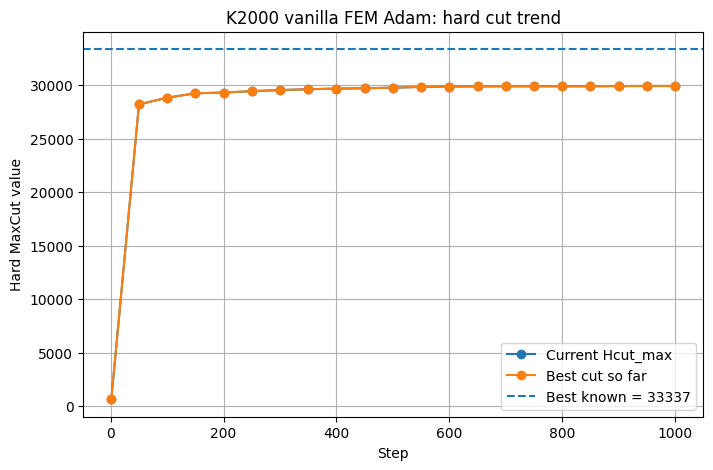

In [28]:
plt.figure(figsize=(8, 5))

plt.plot(df["step"], df["Hcut_max"], marker="o", label="Current Hcut_max")
plt.plot(df["step"], df["best_cut_so_far"], marker="o", label="Best cut so far")
plt.axhline(K2000_BEST_KNOWN, linestyle="--", label=f"Best known = {K2000_BEST_KNOWN}")

plt.xlabel("Step")
plt.ylabel("Hard MaxCut value")
plt.title("K2000 vanilla FEM Adam: hard cut trend")
plt.legend()
plt.grid(True)
plt.show()

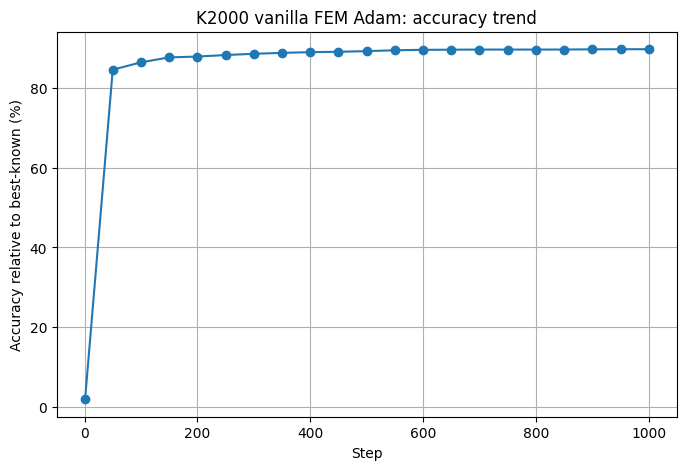

In [29]:
plt.figure(figsize=(8, 5))

plt.plot(df["step"], df["accuracy_so_far_percent"], marker="o")

plt.xlabel("Step")
plt.ylabel("Accuracy relative to best-known (%)")
plt.title("K2000 vanilla FEM Adam: accuracy trend")
plt.grid(True)
plt.show()

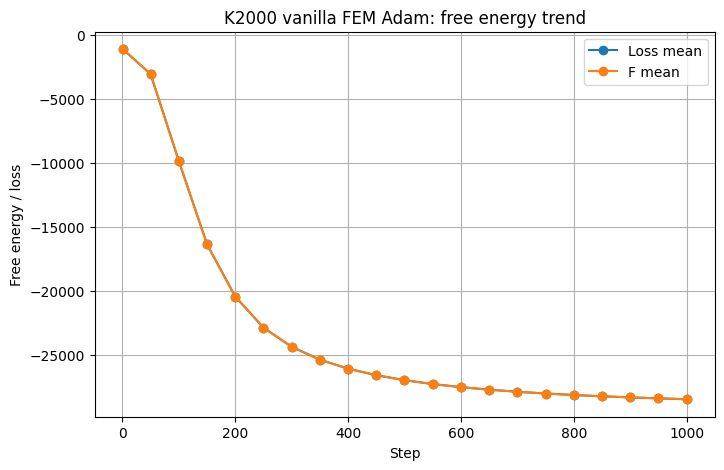

In [30]:
plt.figure(figsize=(8, 5))

plt.plot(df["step"], df["loss_mean"], marker="o", label="Loss mean")
plt.plot(df["step"], df["F_mean"], marker="o", label="F mean")

plt.xlabel("Step")
plt.ylabel("Free energy / loss")
plt.title("K2000 vanilla FEM Adam: free energy trend")
plt.legend()
plt.grid(True)
plt.show()

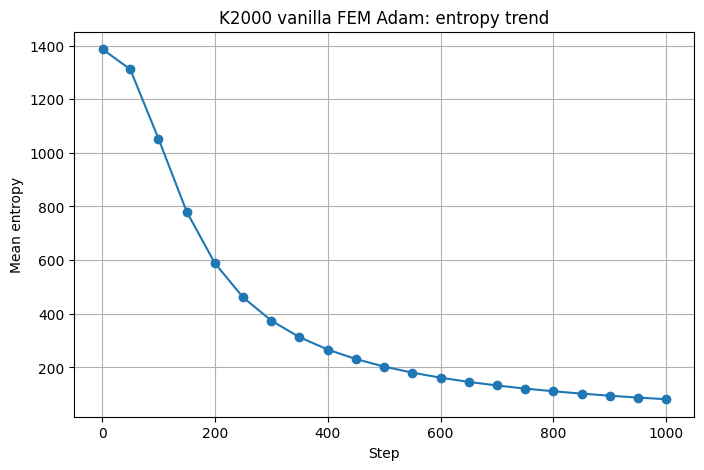

In [31]:
plt.figure(figsize=(8, 5))

plt.plot(df["step"], df["entropy_mean"], marker="o")

plt.xlabel("Step")
plt.ylabel("Mean entropy")
plt.title("K2000 vanilla FEM Adam: entropy trend")
plt.grid(True)
plt.show()

## Advanced run with "BETTER" hyperparams

In [32]:
# ----------------------------
# RMSprop run hyperparameters
# ----------------------------

R_rms = 128
n_steps_rms = 1000

lr_rms = 0.03
alpha_rms = 0.56
momentum_rms = 0.63
weight_decay_rms = 0.013

h_factor_rms = 0.001
seed_rms = 4

log_every_rms = 50

best_known_rms = K2000_BEST_KNOWN
N_rms = W.shape[0]

print("K2000 vanilla FEM RMSprop setup")
print("-" * 80)
print("N:", N_rms)
print("R:", R_rms)
print("n_steps:", n_steps_rms)
print("lr:", lr_rms)
print("alpha:", alpha_rms)
print("momentum:", momentum_rms)
print("weight_decay:", weight_decay_rms)
print("h_factor:", h_factor_rms)
print("seed:", seed_rms)
print("log_every:", log_every_rms)
print("best_known:", best_known_rms)
print("device:", W.device)
print("dtype:", W.dtype)
print("-" * 80)

K2000 vanilla FEM RMSprop setup
--------------------------------------------------------------------------------
N: 2000
R: 128
n_steps: 1000
lr: 0.03
alpha: 0.56
momentum: 0.63
weight_decay: 0.013
h_factor: 0.001
seed: 4
log_every: 50
best_known: 33337
device: mps:0
dtype: torch.float32
--------------------------------------------------------------------------------


In [33]:
torch.manual_seed(seed_rms)
beta_schedule_rms = make_beta_schedule(
    n_steps=n_steps_rms,
    Tmax=K2000_TMAX,
    Tmin=K2000_TMIN,
    device=W.device,
    dtype=W.dtype,
)

print("beta first:", beta_schedule_rms[0].detach().cpu().item())
print("beta last :", beta_schedule_rms[-1].detach().cpu().item())

h_rms = h_factor_rms * torch.randn(
    R_rms,
    N_rms,
    device=W.device,
    dtype=W.dtype,
)

h_rms.requires_grad_(True)

with torch.no_grad():
    p_init_rms = torch.sigmoid(h_rms)

print("\nInitialization check:")
print("h mean:", h_rms.mean().detach().cpu().item())
print("h std :", h_rms.std().detach().cpu().item())
print("p mean:", p_init_rms.mean().detach().cpu().item())
print("p std :", p_init_rms.std().detach().cpu().item())

beta first: 0.8620690107345581
beta last : 16666.66796875

Initialization check:
h mean: -1.0695375749492086e-06
h std : 0.0010001646587625146
p mean: 0.4999997615814209
p std : 0.0002500432019587606


In [34]:
optimizer_rms = torch.optim.RMSprop(
    [h_rms],
    lr=lr_rms,
    alpha=alpha_rms,
    eps=1e-8,
    weight_decay=weight_decay_rms,
    momentum=momentum_rms,
    centered=False,
)

print("\nOptimizer:")
print(optimizer_rms)


Optimizer:
RMSprop (
Parameter Group 0
    alpha: 0.56
    capturable: False
    centered: False
    differentiable: False
    eps: 1e-08
    foreach: None
    lr: 0.03
    maximize: False
    momentum: 0.63
    weight_decay: 0.013
)


In [35]:
history_rms = []

best_cut_rms = None
best_step_rms = None
best_replica_rms = None
best_spins_rms = None
best_p_rms = None

# ----------------------------
# Optimization loop
# ----------------------------

start_time_rms = time.time()

if W.device.type == "mps":
    torch.mps.synchronize()

for step in range(n_steps_rms):
    beta_t = beta_schedule_rms[step]

    # FEM gradient step
    optimizer_rms.zero_grad()

    F_rms = fem_free_energy_maxcut(W, h_rms, beta_t)

    loss_rms = F_rms.mean()

    loss_rms.backward()
    optimizer_rms.step()

    # Logging and hard readout
    should_log = (
        step == 0
        or step == n_steps_rms - 1
        or (step + 1) % log_every_rms == 0
    )

    if should_log:
        if W.device.type == "mps":
            torch.mps.synchronize()

        elapsed_rms = time.time() - start_time_rms

        with torch.no_grad():
            p_rms = torch.sigmoid(h_rms)

            E_cut_rms = expected_cut(W, p_rms)
            S_rms = binary_entropy(p_rms)

            spins_rms = torch.where(
                p_rms >= 0.5,
                torch.ones_like(p_rms),
                -torch.ones_like(p_rms),
            )

            H_cut_rms = discrete_cut(W, spins_rms)

            current_best_cut_rms, current_best_replica_rms = torch.max(H_cut_rms, dim=0)

            current_best_cut_value_rms = float(current_best_cut_rms.detach().cpu().item())
            current_best_replica_value_rms = int(current_best_replica_rms.detach().cpu().item())

            if best_cut_rms is None or current_best_cut_value_rms > best_cut_rms:
                best_cut_rms = current_best_cut_value_rms
                best_step_rms = step + 1
                best_replica_rms = current_best_replica_value_rms
                best_spins_rms = spins_rms[current_best_replica_value_rms].detach().clone()
                best_p_rms = p_rms[current_best_replica_value_rms].detach().clone()

            history_rms.append({
                "step": step + 1,
                "beta": float(beta_t.detach().cpu().item()),

                "loss_mean": float(loss_rms.detach().cpu().item()),
                "F_mean": float(F_rms.mean().detach().cpu().item()),
                "F_min": float(F_rms.min().detach().cpu().item()),

                "Ecut_mean": float(E_cut_rms.mean().detach().cpu().item()),
                "Ecut_max": float(E_cut_rms.max().detach().cpu().item()),

                "entropy_mean": float(S_rms.mean().detach().cpu().item()),

                "Hcut_mean": float(H_cut_rms.mean().detach().cpu().item()),
                "Hcut_max": current_best_cut_value_rms,

                "best_cut_so_far": best_cut_rms,
                "gap_so_far": float(best_known_rms - best_cut_rms),
                "accuracy_so_far_percent": float(100.0 * best_cut_rms / best_known_rms),

                "best_replica_current": current_best_replica_value_rms,
                "best_replica_so_far": best_replica_rms,

                "elapsed_sec": elapsed_rms,
            })

            print(
                f"step {step + 1:5d}/{n_steps_rms} | "
                f"beta={float(beta_t.detach().cpu().item()):10.4f} | "
                f"loss={float(loss_rms.detach().cpu().item()):12.4f} | "
                f"Ecut_max={float(E_cut_rms.max().detach().cpu().item()):10.1f} | "
                f"Hcut_max={current_best_cut_value_rms:10.1f} | "
                f"best={best_cut_rms:10.1f} | "
                f"acc={100.0 * best_cut_rms / best_known_rms:8.4f}% | "
                f"time={elapsed_rms:8.2f}s"
            )

if W.device.type == "mps":
    torch.mps.synchronize()

total_time_sec_rms = time.time() - start_time_rms

step     1/1000 | beta=    0.8621 | loss=  -1088.1013 | Ecut_max=    -523.1 | Hcut_max=   -7247.0 | best=   -7247.0 | acc=-21.7386% | time=    0.11s
step    50/1000 | beta=    0.9065 | loss= -21214.5508 | Ecut_max=   21222.6 | Hcut_max=   30878.0 | best=   30878.0 | acc= 92.6238% | time=    0.24s
step   100/1000 | beta=    0.9569 | loss= -22248.6484 | Ecut_max=   22039.7 | Hcut_max=   31575.0 | best=   31575.0 | acc= 94.7146% | time=    0.51s
step   150/1000 | beta=    1.0132 | loss= -22613.6348 | Ecut_max=   22446.0 | Hcut_max=   31950.0 | best=   31950.0 | acc= 95.8395% | time=    0.70s
step   200/1000 | beta=    1.0765 | loss= -22798.7969 | Ecut_max=   22782.6 | Hcut_max=   32273.0 | best=   32273.0 | acc= 96.8084% | time=    0.90s
step   250/1000 | beta=    1.1483 | loss= -22909.6660 | Ecut_max=   22941.0 | Hcut_max=   32432.0 | best=   32432.0 | acc= 97.2853% | time=    1.09s
step   300/1000 | beta=    1.2303 | loss= -22979.2305 | Ecut_max=   23011.1 | Hcut_max=   32484.0 | best= 

In [36]:
history_k2000_rmsprop = pd.DataFrame(history_rms)

with torch.no_grad():
    p_final_rms = torch.sigmoid(h_rms)

    spins_final_rms = torch.where(
        p_final_rms >= 0.5,
        torch.ones_like(p_final_rms),
        -torch.ones_like(p_final_rms),
    )

    H_final_rms = discrete_cut(W, spins_final_rms)
    E_final_rms = expected_cut(W, p_final_rms)
    S_final_rms = binary_entropy(p_final_rms)
    F_final_rms = fem_free_energy_maxcut(W, h_rms, beta_schedule_rms[-1])

    final_best_cut_rms, final_best_replica_rms = torch.max(H_final_rms, dim=0)

    final_best_cut_rms = float(final_best_cut_rms.detach().cpu().item())
    final_best_replica_rms = int(final_best_replica_rms.detach().cpu().item())

result_k2000_rmsprop = {
    "instance": K2000_INSTANCE,
    "method": "vanilla_fem_rmsprop_autodiff",
    "N": N_rms,
    "R": R_rms,
    "n_steps": n_steps_rms,

    "lr": lr_rms,
    "alpha": alpha_rms,
    "momentum": momentum_rms,
    "weight_decay": weight_decay_rms,

    "h_factor": h_factor_rms,
    "seed": seed_rms,
    "log_every": log_every_rms,
    "best_known_cut": best_known_rms,

    "best_cut": best_cut_rms,
    "best_step": best_step_rms,
    "best_replica": best_replica_rms,
    "gap": float(best_known_rms - best_cut_rms),
    "accuracy_percent": float(100.0 * best_cut_rms / best_known_rms),

    "final_best_cut": final_best_cut_rms,
    "final_best_replica": final_best_replica_rms,
    "final_gap": float(best_known_rms - final_best_cut_rms),
    "final_accuracy_percent": float(100.0 * final_best_cut_rms / best_known_rms),

    "total_time_sec": total_time_sec_rms,

    "best_spins": best_spins_rms.detach().cpu(),
    "best_p": best_p_rms.detach().cpu(),

    "final_H_cuts": H_final_rms.detach().cpu(),
    "final_E_cuts": E_final_rms.detach().cpu(),
    "final_entropy": S_final_rms.detach().cpu(),
    "final_F": F_final_rms.detach().cpu(),
}

print("\nFinished K2000 vanilla FEM RMSprop run.")
print("-" * 80)
print("Best cut:", result_k2000_rmsprop["best_cut"])
print("Best known:", result_k2000_rmsprop["best_known_cut"])
print("Gap:", result_k2000_rmsprop["gap"])
print("Accuracy %:", result_k2000_rmsprop["accuracy_percent"])
print("Best step:", result_k2000_rmsprop["best_step"])
print("Best replica:", result_k2000_rmsprop["best_replica"])
print("Final best cut:", result_k2000_rmsprop["final_best_cut"])
print("Total time sec:", result_k2000_rmsprop["total_time_sec"])
print("-" * 80)


Finished K2000 vanilla FEM RMSprop run.
--------------------------------------------------------------------------------
Best cut: 32954.0
Best known: 33337
Gap: 383.0
Accuracy %: 98.85112637609863
Best step: 1000
Best replica: 15
Final best cut: 32954.0
Total time sec: 4.064090013504028
--------------------------------------------------------------------------------


In [37]:
history_k2000_rmsprop.tail()

,step,beta,loss_mean,F_mean,F_min,Ecut_mean,Ecut_max,entropy_mean,Hcut_mean,Hcut_max,best_cut_so_far,gap_so_far,accuracy_so_far_percent,best_replica_current,best_replica_so_far,elapsed_sec
16,800,4.305146,-23019.794922,-23019.794922,-23749.349609,22876.917969,23605.183594,617.223022,32158.906250,32947.0,32947.0,390.0,98.830129,15,15,3.284163
17,850,5.739701,-23005.480469,-23005.480469,-23734.890625,22898.615234,23625.121094,616.170166,32161.835938,32947.0,32947.0,390.0,98.830129,15,15,3.487101
18,900,8.608070,-22990.945312,-22990.945312,-23715.710938,22919.695312,23647.210938,615.084534,32164.976562,32947.0,32947.0,390.0,98.830129,15,15,3.675662
19,950,17.207260,-22975.087891,-22975.087891,-23698.490234,22939.296875,23665.380859,614.102173,32164.921875,32947.0,32947.0,390.0,98.830129,15,15,3.866642
20,1000,16666.667969,-22959.773438,-22959.773438,-23684.517578,22960.054688,23682.507812,613.075195,32166.625000,32954.0,32954.0,383.0,98.851126,15,15,4.052286


## Performance comparison between Adam and RMS
for the same number of replicas = 128!

In [38]:
adam = result_k2000_adam
rms = result_k2000_rmsprop

df_adam = history_k2000_adam.copy()
df_rms = history_k2000_rmsprop.copy()

# ----------------------------
# Summary table
# ----------------------------

comparison_df = pd.DataFrame([
    {
        "method": "Adam autodiff",
        "R": adam["R"],
        "n_steps": adam["n_steps"],
        "lr": adam["lr"],
        "best_cut": adam["best_cut"],
        "best_known": adam["best_known_cut"],
        "gap": adam["gap"],
        "accuracy_percent": adam["accuracy_percent"],
        "best_step": adam["best_step"],
        "runtime_sec": adam["total_time_sec"],
    },
    {
        "method": "RMSprop autodiff",
        "R": rms["R"],
        "n_steps": rms["n_steps"],
        "lr": rms["lr"],
        "best_cut": rms["best_cut"],
        "best_known": rms["best_known_cut"],
        "gap": rms["gap"],
        "accuracy_percent": rms["accuracy_percent"],
        "best_step": rms["best_step"],
        "runtime_sec": rms["total_time_sec"],
    },
])

display(comparison_df)

,method,R,n_steps,lr,best_cut,best_known,gap,accuracy_percent,best_step,runtime_sec
0,Adam autodiff,128,1000,0.01,29906.0,33337,3431.0,89.708132,950,4.196436
1,RMSprop autodiff,128,1000,0.03,32954.0,33337,383.0,98.851126,1000,4.064090


In [39]:
# ----------------------------
# Direct improvement numbers
# ----------------------------

cut_improvement = rms["best_cut"] - adam["best_cut"]
gap_reduction = adam["gap"] - rms["gap"]
accuracy_gain = rms["accuracy_percent"] - adam["accuracy_percent"]
runtime_ratio = rms["total_time_sec"] / adam["total_time_sec"]

print("Adam vs RMSprop inference")
print("-" * 80)
print("RMSprop cut improvement over Adam:", cut_improvement)
print("Gap reduction:", gap_reduction)
print("Accuracy gain (% points):", accuracy_gain)
print("Runtime ratio RMSprop / Adam:", runtime_ratio)
print("-" * 80)

if cut_improvement > 0:
    print("RMSprop improved the hard cut over Adam.")
elif cut_improvement < 0:
    print("RMSprop performed worse than Adam on this run.")
else:
    print("RMSprop and Adam tied on best hard cut.")

Adam vs RMSprop inference
--------------------------------------------------------------------------------
RMSprop cut improvement over Adam: 3048.0
Gap reduction: 3048.0
Accuracy gain (% points): 9.14299427063024
Runtime ratio RMSprop / Adam: 0.9684622503476907
--------------------------------------------------------------------------------
RMSprop improved the hard cut over Adam.


In [40]:
print("\nAdam final logged row:")
display(df_adam.tail(1))

print("\nRMSprop final logged row:")
display(df_rms.tail(1))


Adam final logged row:


,step,beta,loss_mean,F_mean,F_min,Ecut_mean,Ecut_max,entropy_mean,Hcut_mean,Hcut_max,best_cut_so_far,gap_so_far,accuracy_so_far_percent,best_replica_current,best_replica_so_far,elapsed_sec
20,1000,16666.667969,-28496.222656,-28496.222656,-29246.835938,28497.564453,29248.103516,81.6064,29143.21875,29906.0,29906.0,3431.0,89.708132,116,116,4.184862



RMSprop final logged row:


,step,beta,loss_mean,F_mean,F_min,Ecut_mean,Ecut_max,entropy_mean,Hcut_mean,Hcut_max,best_cut_so_far,gap_so_far,accuracy_so_far_percent,best_replica_current,best_replica_so_far,elapsed_sec
20,1000,16666.667969,-22959.773438,-22959.773438,-23684.517578,22960.054688,23682.507812,613.075195,32166.625,32954.0,32954.0,383.0,98.851126,15,15,4.052286


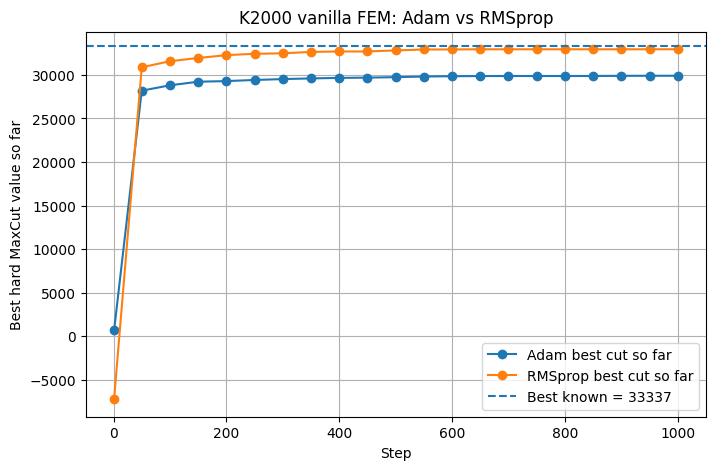

In [41]:
plt.figure(figsize=(8, 5))

plt.plot(
    df_adam["step"],
    df_adam["best_cut_so_far"],
    marker="o",
    label="Adam best cut so far",
)

plt.plot(
    df_rms["step"],
    df_rms["best_cut_so_far"],
    marker="o",
    label="RMSprop best cut so far",
)

plt.axhline(
    K2000_BEST_KNOWN,
    linestyle="--",
    label=f"Best known = {K2000_BEST_KNOWN}",
)

plt.xlabel("Step")
plt.ylabel("Best hard MaxCut value so far")
plt.title("K2000 vanilla FEM: Adam vs RMSprop")
plt.legend()
plt.grid(True)
plt.show()

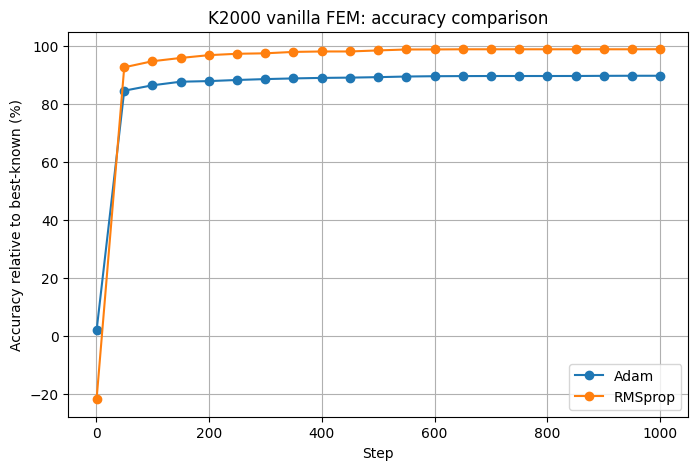

In [42]:
plt.figure(figsize=(8, 5))

plt.plot(
    df_adam["step"],
    df_adam["accuracy_so_far_percent"],
    marker="o",
    label="Adam",
)

plt.plot(
    df_rms["step"],
    df_rms["accuracy_so_far_percent"],
    marker="o",
    label="RMSprop",
)

plt.xlabel("Step")
plt.ylabel("Accuracy relative to best-known (%)")
plt.title("K2000 vanilla FEM: accuracy comparison")
plt.legend()
plt.grid(True)
plt.show()

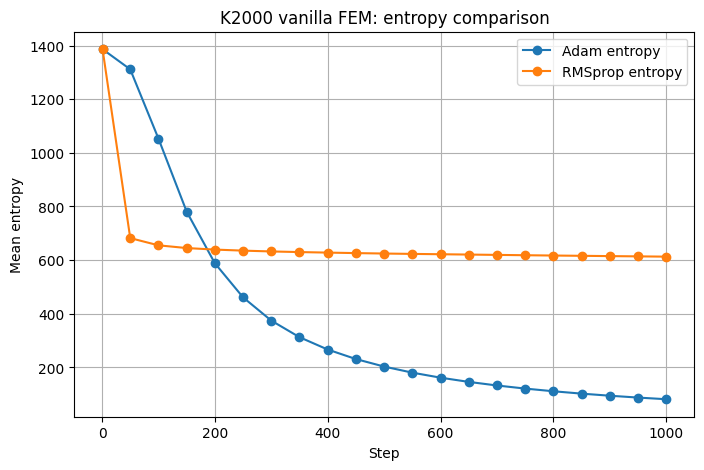

In [43]:
if "entropy_mean" in df_adam.columns and "entropy_mean" in df_rms.columns:
    plt.figure(figsize=(8, 5))

    plt.plot(
        df_adam["step"],
        df_adam["entropy_mean"],
        marker="o",
        label="Adam entropy",
    )

    plt.plot(
        df_rms["step"],
        df_rms["entropy_mean"],
        marker="o",
        label="RMSprop entropy",
    )

    plt.xlabel("Step")
    plt.ylabel("Mean entropy")
    plt.title("K2000 vanilla FEM: entropy comparison")
    plt.legend()
    plt.grid(True)
    plt.show()
else:
    print("entropy_mean missing in one of the histories. No entropy plot.")

In [45]:
# ============================================================
# Cell 13.5 final: compact textual inference
# ============================================================

adam_best = adam["best_cut"]
rms_best = rms["best_cut"]

adam_acc = adam["accuracy_percent"]
rms_acc = rms["accuracy_percent"]

adam_time = adam["total_time_sec"]
rms_time = rms["total_time_sec"]

print("Compact inference")
print("-" * 80)

print(f"Adam best cut    : {adam_best:.0f} ({adam_acc:.4f}%) in {adam_time:.2f}s")
print(f"RMSprop best cut : {rms_best:.0f} ({rms_acc:.4f}%) in {rms_time:.2f}s")

print()

if rms_best > adam_best:
    print("Inference: RMSprop is better than Adam at the same R and n_steps.")
    print("This suggests optimizer dynamics matter, not just replica count.")
elif rms_best < adam_best:
    print("Inference: RMSprop is worse than Adam at the same R and n_steps.")
    print("This suggests advantage is probably not RMSprop alone.")
    print("The missing ingredients are likely row-normalized explicit gradient and larger R.")
else:
    print("Inference: Adam and RMSprop tie at this scale.")
    print("The next useful axis is replica count or explicit row-normalized gradient.")

print("-" * 80)

Compact inference
--------------------------------------------------------------------------------
Adam best cut    : 29906 (89.7081%) in 4.20s
RMSprop best cut : 32954 (98.8511%) in 4.06s

Inference: RMSprop is better than Adam at the same R and n_steps.
This suggests optimizer dynamics matter, not just replica count.
--------------------------------------------------------------------------------


In [46]:
print("Adam final entropy:", history_k2000_adam["entropy_mean"].iloc[-1])
print("RMS final entropy :", history_k2000_rmsprop["entropy_mean"].iloc[-1])

print("Adam best cut:", result_k2000_adam["best_cut"])
print("RMS best cut :", result_k2000_rmsprop["best_cut"])

Adam final entropy: 81.60639953613281
RMS final entropy : 613.0751953125
Adam best cut: 29906.0
RMS best cut : 32954.0


## HIGHER replica values!

In [57]:
# ----------------------------
# Replica ladder settings
# ----------------------------

R_ladder_values = [512, 1024]

n_steps_ladder = 1000
log_every_ladder = 50

# Exact Cell 13 RMSprop-style hyperparameters
lr_ladder = 0.03
alpha_ladder = 0.56
momentum_ladder = 0.63
weight_decay_ladder = 0.013

h_factor_ladder = 0.001
seed_ladder = 4

best_known_ladder = K2000_BEST_KNOWN
N_ladder = W.shape[0]

In [58]:
# ----------------------------
# Fresh storage containers
# ----------------------------

ladder_results_cell13style = {}
ladder_histories_cell13style = {}
ladder_summary_rows_cell13style = []

print("K2000 RMSprop replica ladder: Cell-13-style dynamics")
print("-" * 80)
print("R values:", R_ladder_values)
print("n_steps:", n_steps_ladder)
print("lr:", lr_ladder)
print("alpha:", alpha_ladder)
print("momentum:", momentum_ladder)
print("weight_decay:", weight_decay_ladder)
print("h_factor:", h_factor_ladder)
print("seed:", seed_ladder)
print("device:", W.device)
print("dtype:", W.dtype)
print("-" * 80)

K2000 RMSprop replica ladder: Cell-13-style dynamics
--------------------------------------------------------------------------------
R values: [512, 1024]
n_steps: 1000
lr: 0.03
alpha: 0.56
momentum: 0.63
weight_decay: 0.013
h_factor: 0.001
seed: 4
device: mps:0
dtype: torch.float32
--------------------------------------------------------------------------------


### Replica ladder `R = [512, 1024]` optimization loop

In [59]:
# ============================================================
# Main replica ladder loop
# ============================================================

for R_ladder in R_ladder_values:
    print("\n")
    print("=" * 80)
    print(f"Starting Cell-13-style RMSprop run with R = {R_ladder}")
    print("=" * 80)

    # ----------------------------
    # Reset seed
    # ----------------------------

    torch.manual_seed(seed_ladder)

    # ----------------------------
    # Beta schedule
    # ----------------------------

    beta_schedule_ladder = make_beta_schedule(
        n_steps=n_steps_ladder,
        Tmax=K2000_TMAX,
        Tmin=K2000_TMIN,
        device=W.device,
        dtype=W.dtype,
    )

    # ----------------------------
    # Initialize h near zero
    # ----------------------------

    h_ladder = h_factor_ladder * torch.randn(
        R_ladder,
        N_ladder,
        device=W.device,
        dtype=W.dtype,
    )

    h_ladder.requires_grad_(True)

    with torch.no_grad():
        p_init_ladder = torch.sigmoid(h_ladder)

    print("Initialization:")
    print("h mean:", h_ladder.mean().detach().cpu().item())
    print("h std :", h_ladder.std().detach().cpu().item())
    print("p mean:", p_init_ladder.mean().detach().cpu().item())
    print("p std :", p_init_ladder.std().detach().cpu().item())

    # ----------------------------
    # RMSprop optimizer
    # ----------------------------

    optimizer_ladder = torch.optim.RMSprop(
        [h_ladder],
        lr=lr_ladder,
        alpha=alpha_ladder,
        eps=1e-8,
        weight_decay=weight_decay_ladder,
        momentum=momentum_ladder,
        centered=False,
    )

    # ----------------------------
    # Tracking
    # ----------------------------

    history_ladder = []

    best_cut_ladder = None
    best_step_ladder = None
    best_replica_ladder = None
    best_spins_ladder = None
    best_p_ladder = None

    stopped_early = False
    stop_reason = None
    stop_step = None

    start_time_ladder = time.time()

    if W.device.type == "mps":
        torch.mps.synchronize()

    # ========================================================
    # Optimization loop
    # ========================================================

    for step in range(n_steps_ladder):
        beta_t = beta_schedule_ladder[step]

        optimizer_ladder.zero_grad()

        F_ladder = fem_free_energy_maxcut(W, h_ladder, beta_t)

        # ----------------------------
        # NaN/Inf check before backward
        # ----------------------------

        if not torch.isfinite(F_ladder).all():
            stopped_early = True
            stop_reason = "Non-finite F_ladder before backward"
            stop_step = step + 1
            print(f"\nSTOPPING R={R_ladder}: {stop_reason} at step {stop_step}")
            break

        # Exact Cell 13 style:
        loss_ladder = F_ladder.mean()

        if not torch.isfinite(loss_ladder):
            stopped_early = True
            stop_reason = "Non-finite loss_ladder before backward"
            stop_step = step + 1
            print(f"\nSTOPPING R={R_ladder}: {stop_reason} at step {stop_step}")
            break

        loss_ladder.backward()

        # ----------------------------
        # NaN/Inf check on gradient
        # ----------------------------

        if h_ladder.grad is None:
            stopped_early = True
            stop_reason = "h_ladder.grad is None"
            stop_step = step + 1
            print(f"\nSTOPPING R={R_ladder}: {stop_reason} at step {stop_step}")
            break

        if not torch.isfinite(h_ladder.grad).all():
            stopped_early = True
            stop_reason = "Non-finite h_ladder.grad before optimizer step"
            stop_step = step + 1
            print(f"\nSTOPPING R={R_ladder}: {stop_reason} at step {stop_step}")
            break

        optimizer_ladder.step()

        # ----------------------------
        # NaN/Inf check after update
        # ----------------------------

        if not torch.isfinite(h_ladder).all():
            stopped_early = True
            stop_reason = "Non-finite h_ladder after optimizer step"
            stop_step = step + 1
            print(f"\nSTOPPING R={R_ladder}: {stop_reason} at step {stop_step}")
            break

        # ----------------------------
        # Logging
        # ----------------------------

        should_log = (
            step == 0
            or step == n_steps_ladder - 1
            or (step + 1) % log_every_ladder == 0
        )

        if should_log:
            if W.device.type == "mps":
                torch.mps.synchronize()

            elapsed_ladder = time.time() - start_time_ladder

            with torch.no_grad():
                p_ladder = torch.sigmoid(h_ladder)

                E_cut_ladder = expected_cut(W, p_ladder)
                S_ladder = binary_entropy(p_ladder)

                spins_ladder = torch.where(
                    p_ladder >= 0.5,
                    torch.ones_like(p_ladder),
                    -torch.ones_like(p_ladder),
                )

                H_cut_ladder = discrete_cut(W, spins_ladder)

                current_best_cut_ladder, current_best_replica_ladder = torch.max(
                    H_cut_ladder,
                    dim=0,
                )

                current_best_cut_value_ladder = float(
                    current_best_cut_ladder.detach().cpu().item()
                )

                current_best_replica_value_ladder = int(
                    current_best_replica_ladder.detach().cpu().item()
                )

                if best_cut_ladder is None or current_best_cut_value_ladder > best_cut_ladder:
                    best_cut_ladder = current_best_cut_value_ladder
                    best_step_ladder = step + 1
                    best_replica_ladder = current_best_replica_value_ladder
                    best_spins_ladder = spins_ladder[current_best_replica_value_ladder].detach().clone()
                    best_p_ladder = p_ladder[current_best_replica_value_ladder].detach().clone()

                history_ladder.append({
                    "R": R_ladder,
                    "step": step + 1,
                    "beta": float(beta_t.detach().cpu().item()),

                    "loss_mean": float(loss_ladder.detach().cpu().item()),
                    "F_mean": float(F_ladder.mean().detach().cpu().item()),
                    "F_min": float(F_ladder.min().detach().cpu().item()),

                    "Ecut_mean": float(E_cut_ladder.mean().detach().cpu().item()),
                    "Ecut_max": float(E_cut_ladder.max().detach().cpu().item()),

                    "entropy_mean": float(S_ladder.mean().detach().cpu().item()),

                    "Hcut_mean": float(H_cut_ladder.mean().detach().cpu().item()),
                    "Hcut_max": current_best_cut_value_ladder,

                    "best_cut_so_far": best_cut_ladder,
                    "gap_so_far": float(best_known_ladder - best_cut_ladder),
                    "accuracy_so_far_percent": float(
                        100.0 * best_cut_ladder / best_known_ladder
                    ),

                    "best_replica_current": current_best_replica_value_ladder,
                    "best_replica_so_far": best_replica_ladder,

                    "elapsed_sec": elapsed_ladder,
                })

                print(
                    f"R={R_ladder:4d} | "
                    f"step {step + 1:5d}/{n_steps_ladder} | "
                    f"beta={float(beta_t.detach().cpu().item()):10.4f} | "
                    f"F_mean={float(F_ladder.mean().detach().cpu().item()):12.4f} | "
                    f"Ecut_max={float(E_cut_ladder.max().detach().cpu().item()):10.1f} | "
                    f"Hcut_max={current_best_cut_value_ladder:10.1f} | "
                    f"best={best_cut_ladder:10.1f} | "
                    f"acc={100.0 * best_cut_ladder / best_known_ladder:8.4f}% | "
                    f"time={elapsed_ladder:8.2f}s"
                )

    if W.device.type == "mps":
        torch.mps.synchronize()

    total_time_sec_ladder = time.time() - start_time_ladder

    # ----------------------------
    # Final readout
    # ----------------------------

    with torch.no_grad():
        p_final_ladder = torch.sigmoid(h_ladder)

        spins_final_ladder = torch.where(
            p_final_ladder >= 0.5,
            torch.ones_like(p_final_ladder),
            -torch.ones_like(p_final_ladder),
        )

        H_final_ladder = discrete_cut(W, spins_final_ladder)
        E_final_ladder = expected_cut(W, p_final_ladder)
        S_final_ladder = binary_entropy(p_final_ladder)

        final_beta_index = min(step, n_steps_ladder - 1)

        F_final_ladder = fem_free_energy_maxcut(
            W,
            h_ladder,
            beta_schedule_ladder[final_beta_index],
        )

        final_best_cut_ladder, final_best_replica_ladder = torch.max(
            H_final_ladder,
            dim=0,
        )

        final_best_cut_ladder = float(final_best_cut_ladder.detach().cpu().item())
        final_best_replica_ladder = int(final_best_replica_ladder.detach().cpu().item())

    # ----------------------------
    # Store history and result
    # ----------------------------

    history_df_ladder = pd.DataFrame(history_ladder)

    result_ladder = {
        "instance": K2000_INSTANCE,
        "method": "vanilla_fem_rmsprop_autodiff_cell13style_replica_ladder",

        "N": N_ladder,
        "R": R_ladder,
        "n_steps": n_steps_ladder,

        "lr": lr_ladder,
        "alpha": alpha_ladder,
        "momentum": momentum_ladder,
        "weight_decay": weight_decay_ladder,

        "h_factor": h_factor_ladder,
        "seed": seed_ladder,
        "log_every": log_every_ladder,

        "best_known_cut": best_known_ladder,

        "best_cut": best_cut_ladder,
        "best_step": best_step_ladder,
        "best_replica": best_replica_ladder,
        "gap": float(best_known_ladder - best_cut_ladder),
        "accuracy_percent": float(100.0 * best_cut_ladder / best_known_ladder),

        "final_best_cut": final_best_cut_ladder,
        "final_best_replica": final_best_replica_ladder,
        "final_gap": float(best_known_ladder - final_best_cut_ladder),
        "final_accuracy_percent": float(
            100.0 * final_best_cut_ladder / best_known_ladder
        ),

        "total_time_sec": total_time_sec_ladder,

        "stopped_early": stopped_early,
        "stop_reason": stop_reason,
        "stop_step": stop_step,

        "best_spins": best_spins_ladder.detach().cpu() if best_spins_ladder is not None else None,
        "best_p": best_p_ladder.detach().cpu() if best_p_ladder is not None else None,

        "final_H_cuts": H_final_ladder.detach().cpu(),
        "final_E_cuts": E_final_ladder.detach().cpu(),
        "final_entropy": S_final_ladder.detach().cpu(),
        "final_F": F_final_ladder.detach().cpu(),
    }

    ladder_results_cell13style[R_ladder] = result_ladder
    ladder_histories_cell13style[R_ladder] = history_df_ladder

    ladder_summary_rows_cell13style.append({
        "method": "RMSprop Cell13-style",
        "R": R_ladder,
        "n_steps": n_steps_ladder,
        "best_cut": result_ladder["best_cut"],
        "best_known": result_ladder["best_known_cut"],
        "gap": result_ladder["gap"],
        "accuracy_percent": result_ladder["accuracy_percent"],
        "best_step": result_ladder["best_step"],
        "runtime_sec": result_ladder["total_time_sec"],
        "final_best_cut": result_ladder["final_best_cut"],
        "final_accuracy_percent": result_ladder["final_accuracy_percent"],
        "stopped_early": result_ladder["stopped_early"],
        "stop_step": result_ladder["stop_step"],
        "stop_reason": result_ladder["stop_reason"],
    })

    print("\nFinished Cell-13-style R =", R_ladder)
    print("-" * 80)
    print("Best cut:", result_ladder["best_cut"])
    print("Best known:", result_ladder["best_known_cut"])
    print("Gap:", result_ladder["gap"])
    print("Accuracy %:", result_ladder["accuracy_percent"])
    print("Best step:", result_ladder["best_step"])
    print("Best replica:", result_ladder["best_replica"])
    print("Final best cut:", result_ladder["final_best_cut"])
    print("Total time sec:", result_ladder["total_time_sec"])
    print("Stopped early:", result_ladder["stopped_early"])
    print("Stop reason:", result_ladder["stop_reason"])
    print("-" * 80)

    # ----------------------------
    # Clean temporary tensors before next R
    # ----------------------------

    del h_ladder
    del optimizer_ladder
    del F_ladder
    del loss_ladder
    del p_final_ladder
    del spins_final_ladder
    del H_final_ladder
    del E_final_ladder
    del S_final_ladder
    del F_final_ladder

    if W.device.type == "mps":
        torch.mps.empty_cache()



Starting Cell-13-style RMSprop run with R = 512
Initialization:
h mean: -3.563236816717108e-07
h std : 0.0009989672107622027
p mean: 0.4999999403953552
p std : 0.00024974383995868266
R= 512 | step     1/1000 | beta=    0.8621 | F_mean=  -1088.1011 | Ecut_max=    -525.9 | Hcut_max=  -12571.0 | best=  -12571.0 | acc=-37.7089% | time=    0.04s
R= 512 | step    50/1000 | beta=    0.9065 | F_mean=  -8045.4424 | Ecut_max=    7083.6 | Hcut_max=   31995.0 | best=   31995.0 | acc= 95.9744% | time=    0.97s
R= 512 | step   100/1000 | beta=    0.9569 | F_mean=  -8190.2100 | Ecut_max=    7113.1 | Hcut_max=   32031.0 | best=   32031.0 | acc= 96.0824% | time=    2.26s
R= 512 | step   150/1000 | beta=    1.0132 | F_mean=  -8192.8936 | Ecut_max=    7145.0 | Hcut_max=   32020.0 | best=   32031.0 | acc= 96.0824% | time=    3.08s
R= 512 | step   200/1000 | beta=    1.0765 | F_mean=  -8172.1006 | Ecut_max=    7173.6 | Hcut_max=   32064.0 | best=   32064.0 | acc= 96.1814% | time=    3.94s
R= 512 | step  

In [60]:
# ----------------------------
# Final ladder summary
# ----------------------------

ladder_summary_cell13style_df = pd.DataFrame(ladder_summary_rows_cell13style)

print("\nCell-13-style replica ladder summary:")
display(ladder_summary_cell13style_df)


Cell-13-style replica ladder summary:


,method,R,n_steps,best_cut,best_known,gap,accuracy_percent,best_step,runtime_sec,final_best_cut,final_accuracy_percent,stopped_early,stop_step,stop_reason
0,RMSprop Cell13-style,512,1000,32260.0,33337,1077.0,96.769355,1000,18.054986,32260.0,96.769355,False,None,None
1,RMSprop Cell13-style,1024,1000,-7695.0,33337,41032.0,-23.082461,600,35.269672,-8104.0,-24.309326,False,None,None


In [61]:
# ============================================================
# Compare Adam, RMSprop R=128, and Cell-13-style ladder
# ============================================================

comparison_rows = []

comparison_rows.append({
    "method": "Adam autodiff",
    "R": result_k2000_adam["R"],
    "best_cut": result_k2000_adam["best_cut"],
    "gap": result_k2000_adam["gap"],
    "accuracy_percent": result_k2000_adam["accuracy_percent"],
    "runtime_sec": result_k2000_adam["total_time_sec"],
    "best_step": result_k2000_adam["best_step"],
})

comparison_rows.append({
    "method": "RMSprop autodiff R=128",
    "R": result_k2000_rmsprop["R"],
    "best_cut": result_k2000_rmsprop["best_cut"],
    "gap": result_k2000_rmsprop["gap"],
    "accuracy_percent": result_k2000_rmsprop["accuracy_percent"],
    "runtime_sec": result_k2000_rmsprop["total_time_sec"],
    "best_step": result_k2000_rmsprop["best_step"],
})

for R_value, result in ladder_results_cell13style.items():
    comparison_rows.append({
        "method": f"RMSprop Cell13-style R={R_value}",
        "R": result["R"],
        "best_cut": result["best_cut"],
        "gap": result["gap"],
        "accuracy_percent": result["accuracy_percent"],
        "runtime_sec": result["total_time_sec"],
        "best_step": result["best_step"],
        "stopped_early": result["stopped_early"],
        "stop_step": result["stop_step"],
    })

k2000_method_comparison_cell13style_df = pd.DataFrame(comparison_rows).sort_values(
    ["R", "method"]
)

display(k2000_method_comparison_cell13style_df)

,method,R,best_cut,gap,accuracy_percent,runtime_sec,best_step,stopped_early,stop_step
0,Adam autodiff,128,29906.0,3431.0,89.708132,4.196436,950,NaN,NaN
1,RMSprop autodiff R=128,128,32954.0,383.0,98.851126,4.064090,1000,NaN,NaN
2,RMSprop Cell13-style R=512,512,32260.0,1077.0,96.769355,18.054986,1000,False,NaN
3,RMSprop Cell13-style R=1024,1024,-7695.0,41032.0,-23.082461,35.269672,600,False,NaN
